**Notebook Status:** 
> This notebook version disables (comments out) the code corresponding to running the notebook with the MC signal samples, as they are not available in the '2025e-13tev-beta' release used here. The commented-out signal samples are included for transparency, and future reproducibility. 

> This analysis can be run with the data and background MC samples, with the recommended skim '2to4lep' corresponding to events with two to four leptons in the final state.

# Exploring a Search for Supersymmetric Dark Matter
This notebook guides you through a supersymmetry-motived dark matter search using the ATLAS Open Data. We will explore proton-proton collision events containing two lepton and missing transverse energy in the final state. By the end of this notebook, we will have reproduced a simplified analysis, including a cutflow table, histogram, and a basic statistical interpretation of the results.

## What is Dark Matter?
Ordinary matter, which can be observed and studied, makes up around 5% of the universe. About 27% of the matter in the Universe is dark matter, yet its properties remain one of the mysteries in modern physics research.


Evidence for dark matter primarily comes from astronomical observations. One example is gravitational lensing, where gravity can bend light and distort the appearance of the galaxies in a way that cannot be explained by visible matter alone. These types of astronomical observations have led to many dark matter theories, some of which suggest that dark matter may be a new, currently undiscovered particle. These ideas are what motivate experimental searches in particle physics. 


## The Standard Model and Beyond the Standard Model
The Standard Model describes our current understanding of three of the four fundamental forces: electromagnetic, weak, and strong forces, excluding gravity. It classifies the known elementary particles, including the particles that make up matter (fermions) and the particles that facilitate the interactions (bosons).
Beyond the Standard Model physics describes processes and phenomena that we cannot explain with our current understanding of the Standard Model. For example, the Standard Model does not currently provide a dark matter candidate particle. This motivates new theoretical frameworks that aim to explain these phenomena.




## Supersymmetry: Extending the Standard Model
Supersymmetry (often called 'SUSY' for short) is a theoretical extension of the Standard Model that introduces a symmetry between fermions and bosons, and hypothesizes a range of new particles. These particles are the super-partners of their corresponding Standard Model particle. Within supersymmetry, neutralinos are often considered promising dark matter candidates. In particular, the lightest neutralino is a leading dark matter candidate due to being neutrally charged, weakly interacting, and stable fitting the expected properties of dark matter.



In this notebook, we will focus on a supersyemmetric model preditcing chargino-neutralino production in proton-proton collisions. This process leads to a final state with two charged leptons and missing transverse energy. The Z boson decays into a pair of charged leptons($\ell$) which form the visible part of the final state, while the W boson decays hadronically, producing jets.


We can visualize this model, where protons collide to produce a chargino ($\tilde{X}^{\pm}_1$) and a neutralino ($\tilde{X}^{0}_2$)  with W and Z boson decays. Both the chargino and neutralino would decay into the lightest neutralino ($\tilde{X}^{0}_1$). The lightest neutralinos contribute to the missing transverse energy in our process.




## Searching for Invisible Particles in Collider Experiments:
High-energy particle accelerators, such as the Large Hadron Collider (LHC), play a key role in testing, constraining, and validating theoretical models and frameworks. These accelerators collide particles at extremely high energies, allowing us to study a wide range of processes. Although some particles (like our proposed dark matter candidates) cannot be directly detected and observed, we can infer their presence from an imbalance of measured energy and momentum of the visible particles. This is why missing transverse energy is a key experimental signature in our search for dark matter and supersymmetric particles. A Toroidal LHC AppartuS (ATLAS) is one of the general purpose detectors at the LHC and we will use data from the ATLAS experiment in this analysis.


# Jupyter Notebooks
This notebook provides a way to analyze the data and perform an analysis all in a single file. 

### Running the Notebook:
- To run the entire notebook, click Cell $\rightarrow$ Run All in the top menu.
- To run an individual cell, click Cell $\rightarrow$ Run Cells in the top menu, or use the Shift+Enter keyboard shortcut.

#### Possible Errors:
If a cell produces an error or unexpected result, try to:
1. Read the error message carefully (sometimes a simple variable mismatch is all it takes to produce an error)
2. Revert the notebook to your last checkpoint (essentially a save point) and run the cell again.


Run the next cell to install and update any required packages.

In [ ]:
# only need to run this cell the first time you open this notebook on your computer
import sys

# # update the pip package installer
!{sys.executable} -m pip install --upgrade --user pip
# install required packages
!{sys.executable} -m pip install --upgrade --user uproot awkward vector numpy matplotlib mt2 pandas

These are the python packages that will help us run our analysis.

In [1]:
# run this cell everytime you run the notebook
import os
import os.path

import re # for naming
import uproot # for reading .root files
import awkward as ak # to represent nested data in columnar format
import vector # for 4-momentum calculations
import time # for tracking runtimes
import math # for mathemantical functions such as sqaure root
import numpy as np # for numerical calculations such as histogramming
import pandas as pd # to data file saving
from mt2 import mt2 # for stransverse math calculation
import matplotlib.pyplot as plt # for plotting
from matplotlib.ticker import LogLocator, AutoMinorLocator, NullFormatter # plotting tick marks

import atlasopenmagic as atom # retreiving samples

### Loading the Data
First, we read in the data from where it's stored. Here, we will also define some unit definitions.

In [2]:
# define luminosity for our dataset
lumi = 36.0  # units of fb^-1 (inverse femtobarn)

# define values
GeV = 1.0  # gigaelectron-volts

fraction = 1.0 # reduce this if you want the code to run quicker (helpful when debugging)

atom.set_release('2025e-13tev-beta')   # set the open data release                                                                                                     
skim = "2J2LMET30"  # analysis skim                  
#skim = "2to4lep"  # analysis skim                                                                                                   

Fetching metadata for release: 2025e-13tev-beta...
Fetching datasets: 100%|██████████| 374/374 [00:00<00:00, 822.58datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


### Choosing the Samples
We create a dictionary to organize and hold our event samples, grouping similar samples by the type of physics process they represent. 

An event is a snapshot of the detector taken during a proton-proton collision containing all the reconstructed particles and detector information from that moment. Data events are collected from real collisions recorded by the detector. Monte Carlo (MC) events are simulated and model the physics processes for the backgrounds and signals. 


**Which samples do we include?**
- **Data**: we use all available samples included in our analysis skim. The dataset we will use corresponds to the 2015-2016 data taking period. 
- **Background MC**: this selection depends on the physics process we are studying. For our analysis, which focuses on two lepton final states mediated by W and Z bosons with missing transverse energy, we include the processes that would mimic our signal.
- **Signal MC**: this selection depends on the specific process and mass regions we want to study. Unlike the background process we will keep the signal samples separate so we can analyze specific mass pairings(splittings) or combinations.


**Sample Names:**
The MC event names are stored by a unique idetifier called the datasetID or DSID.
- Check out the [metadata table](https://opendata.atlas.cern/docs/data/for_education/13TeV25_metadata):
    - Search by the dataset IDs (dids) we included to learn more about which processes each smaple grouping contain.
    - Columns describe the process, generator information, and some keywords to help classify each sample.
    - Includes all the MC samples avaible in this ATLAS Open Data release.


In [3]:
# Create a samples dictionary to hold our data, background MC, and signal MC samples
sample_defs = {
    'data':{'dids':['data']},
    
    ##Background Samples
    r'W+jets':{'dids': ['700338', '700339', '700340', 
                        '700341', '700342', '700343']},

    r'Z+jets':{'dids': ['700320', '700321', '700322',
                        '700323', '700324', '700325']},
    
    r'diboson':{'dids': ['700492', '700493', '700494',
                         '700600', '700601']},
    
    r'SingleTop':{'dids': ['601624', '601628']},

    r'ttbar':{'dids':['410470'] },
    
    ## Signal Samples: 'Signal_CharginoNeutralino_WZBosonsDecay_CharginoMass_LightestNeutralinoMass'
#     r'Signal_C1N2_WZ_200_0':   {'dids': ['563381', '563239']},
    
#     r'Signal_C1N2_WZ_250_0':   {'dids': ['563383', '563241']},
#     r'Signal_C1N2_WZ_250_100': {'dids': ['563385', '563243']},
    
#     r'Signal_C1N2_WZ_300_0':   {'dids': ['563386', '563244']},
#     r'Signal_C1N2_WZ_300_100': {'dids': ['563388', '563246']},
    
#     r'Signal_C1N2_WZ_350_0':   {'dids': ['563390', '563248']},
#     r'Signal_C1N2_WZ_350_100': {'dids': ['563392', '563250']},
#     r'Signal_C1N2_WZ_350_200': {'dids': ['563394', '563252']},
    
#     r'Signal_C1N2_WZ_400_0':   {'dids': ['563395', '563253']},
#     r'Signal_C1N2_WZ_400_100': {'dids': ['563397', '563255']},
#     r'Signal_C1N2_WZ_400_200': {'dids': ['563399', '563257']},
    
#     r'Signal_C1N2_WZ_450_0':   {'dids': ['563401', '563259']},
#     r'Signal_C1N2_WZ_450_100': {'dids': ['563403', '563261']},
#     r'Signal_C1N2_WZ_450_200': {'dids': ['563405', '563263']},
#     r'Signal_C1N2_WZ_450_300': {'dids': ['563407', '563265']},
    
#     r'Signal_C1N2_WZ_500_0':   {'dids': ['563408', '563266']},
#     r'Signal_C1N2_WZ_500_100': {'dids': ['563410', '563268']},
#     r'Signal_C1N2_WZ_500_200': {'dids': ['563412', '563270']},
#     r'Signal_C1N2_WZ_500_300': {'dids': ['563414', '563272']},
    
#     r'Signal_C1N2_WZ_550_0':   {'dids': ['563416', '563274']},
#     r'Signal_C1N2_WZ_550_100': {'dids': ['563418', '563276']},
#     r'Signal_C1N2_WZ_550_200': {'dids': ['563420', '563278']},
#     r'Signal_C1N2_WZ_550_300': {'dids': ['563422', '563280']},
#     r'Signal_C1N2_WZ_550_400': {'dids': ['563424', '563282']},
             
#     r'Signal_C1N2_WZ_600_0':   {'dids': ['563425', '563283']},
#     r'Signal_C1N2_WZ_600_100': {'dids': ['563427', '563285']},
#     r'Signal_C1N2_WZ_600_200': {'dids': ['563429', '563287']},
#     r'Signal_C1N2_WZ_600_300': {'dids': ['563431', '563289']},
#     r'Signal_C1N2_WZ_600_400': {'dids': ['563433', '563291']},
    
#     r'Signal_C1N2_WZ_650_0':   {'dids': ['563435', '563293']},
#     r'Signal_C1N2_WZ_650_100': {'dids': ['563437', '563295']},
#     r'Signal_C1N2_WZ_650_200': {'dids': ['563439', '563297']},
#     r'Signal_C1N2_WZ_650_300': {'dids': ['563441', '563299']},
#     r'Signal_C1N2_WZ_650_400': {'dids': ['563443', '563301']},
#     r'Signal_C1N2_WZ_650_500': {'dids': ['563445', '563303']},
    
#     r'Signal_C1N2_WZ_700_0':   {'dids': ['563446', '563304']},
#     r'Signal_C1N2_WZ_700_100': {'dids': ['563448', '563306']},
#     r'Signal_C1N2_WZ_700_200': {'dids': ['563450', '563308']},
#     r'Signal_C1N2_WZ_700_300': {'dids': ['563452', '563310']},
#     r'Signal_C1N2_WZ_700_400': {'dids': ['563454', '563312']},
#     r'Signal_C1N2_WZ_700_500': {'dids': ['563456', '563314']},
             
#     r'Signal_C1N2_WZ_750_0':   {'dids': ['563457', '563315']},
#     r'Signal_C1N2_WZ_750_100': {'dids': ['563459', '563317']},
#     r'Signal_C1N2_WZ_750_200': {'dids': ['563461', '563319']},
#     r'Signal_C1N2_WZ_750_300': {'dids': ['563463', '563321']},
#     r'Signal_C1N2_WZ_750_400': {'dids': ['563465', '563323']},
#     r'Signal_C1N2_WZ_750_500': {'dids': ['563467', '563325']},
             
#     r'Signal_C1N2_WZ_800_0':   {'dids': ['563468', '563326']},
#     r'Signal_C1N2_WZ_800_100': {'dids': ['563470', '563328']},
#     r'Signal_C1N2_WZ_800_200': {'dids': ['563472', '563330']},
#     r'Signal_C1N2_WZ_800_300': {'dids': ['563474', '563332']},
#     r'Signal_C1N2_WZ_800_400': {'dids': ['563476', '563334']},
#     r'Signal_C1N2_WZ_800_500': {'dids': ['563478', '563336']},
    
#     r'Signal_C1N2_WZ_900_0':   {'dids': ['563479', '563337']},
#     r'Signal_C1N2_WZ_900_100': {'dids': ['563481', '563339']},
#     r'Signal_C1N2_WZ_900_200': {'dids': ['563483', '563341']},
#     r'Signal_C1N2_WZ_900_300': {'dids': ['563485', '563343']},
#     r'Signal_C1N2_WZ_900_400': {'dids': ['563487', '563345']},
#     r'Signal_C1N2_WZ_900_500': {'dids': ['563489', '563347']},
    
#     r'Signal_C1N2_WZ_1000_0':   {'dids': ['563490', '563348']},
#     r'Signal_C1N2_WZ_1000_100': {'dids': ['563492', '563350']},
#     r'Signal_C1N2_WZ_1000_200': {'dids': ['563494', '563352']},
#     r'Signal_C1N2_WZ_1000_300': {'dids': ['563496', '563354']},
#     r'Signal_C1N2_WZ_1000_400': {'dids': ['563498', '563356']},
#     r'Signal_C1N2_WZ_1000_500': {'dids': ['563500', '563358']},
    
#     r'Signal_C1N2_WZ_1100_0':   {'dids': ['563501', '563359']},
#     r'Signal_C1N2_WZ_1100_100': {'dids': ['563503', '563361']},
#     r'Signal_C1N2_WZ_1100_200': {'dids': ['563505', '563363']},
#     r'Signal_C1N2_WZ_1100_300': {'dids': ['563507', '563365']},
#     r'Signal_C1N2_WZ_1100_400': {'dids': ['563509', '563367']},
#     r'Signal_C1N2_WZ_1100_500': {'dids': ['563511', '563369']},
             
#     r'Signal_C1N2_WZ_1200_0':   {'dids': ['563512', '563370']},
#     r'Signal_C1N2_WZ_1200_100': {'dids': ['563514', '563372']},
#     r'Signal_C1N2_WZ_1200_200': {'dids': ['563516', '563374']},
#     r'Signal_C1N2_WZ_1200_300': {'dids': ['563518', '563376']},
#     r'Signal_C1N2_WZ_1200_400': {'dids': ['563520', '563378']},
#     r'Signal_C1N2_WZ_1200_500': {'dids': ['563522', '563380']}

}

samples = atom.build_dataset(sample_defs, skim=skim, protocol='https', cache=True) # create the dataset for our defined samples

## Inspecting the Dataset
Now that we have chosen which event samples to include in our analysis, we can inspect the files to learn more about their structure. Let's open the first data sample file and see what information we have. 

There are many things we can look at in each file, the next cell gives you an example of a few.


**Try it yourself!** Open a different MC sample file and inspect its variables or look at other variables for this data sample.

In [4]:
# choose the dataset we want to open
data15_periodD = samples['data']['list'][0]
print(f"{data15_periodD = }")

# open the file
data_tree = uproot.open(data15_periodD + ":analysis")


# inspect the data
# show a list of variables that are available in the file
print('keys = ', data_tree.keys())

#show the number of entries(events) in that file
print('Number of entries = ', data_tree.num_entries)

# show the the met values in the first 5 events
print('MET (first 5 events):', ak.to_list(data_tree.arrays(['met'], entry_stop=5)['met']))

# show some other variables for the first 5 events (group the variables by the event)
example_arrays = data_tree.arrays(['lep_n', 'lep_pt'])
for i in range(5):
    print(f"\nEvent {i}:") # Remember: in programming 0 represents the first entry
    print(f"  Number of leptons: {example_arrays['lep_n'][i]}")
    print(f"  Lepton Momentum: {example_arrays['lep_pt'][i]}")

data15_periodD = 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2J2LMET30_data15_periodD.2J2LMET30.root'
keys =  ['num_events', 'sum_of_weights', 'sum_of_weights_squared', 'category', 'sig_lep', 'n_sig_lep', 'TriggerMatch_DILEPTON', 'ScaleFactor_MLTRIGGER', 'ScaleFactor_PILEUP', 'ScaleFactor_FTAG', 'mcWeight', 'xsec', 'filteff', 'kfac', 'channelNumber', 'eventNumber', 'runNumber', 'trigML', 'trigP', 'trigDT', 'trigT', 'trigE', 'trigDM', 'trigDE', 'trigM', 'trigMET', 'ScaleFactor_BTAG', 'ScaleFactor_JVT', 'jet_n', 'jet_pt', 'jet_eta', 'jet_phi', 'jet_e', 'jet_btag_quantile', 'jet_jvt', 'largeRJet_n', 'largeRJet_pt', 'largeRJet_eta', 'largeRJet_phi', 'largeRJet_e', 'largeRJet_m', 'largeRJet_D2', 'jet_pt_jer1', 'jet_pt_jer2', 'ScaleFactor_ELE', 'ScaleFactor_MUON', 'ScaleFactor_LepTRIGGER', 'ScaleFactor_MuTRIGGER', 'ScaleFactor_ElTRIGGER', 'lep_n', 'lep_type', 'lep_pt', 'lep_eta', 'lep_phi', 'lep_e', 'lep_charge', 'lep_ptvarcone30', 'lep_topoetcone

## MC Weights

Since simulations are generated in an ideal environment, applying weights and scale factors is important to accurately compare MC to data. We apply weights that account for the differences between the simulation and the real detector conditions.

Cross section weights scale the number of simulated events to match the expected rate in the detector using the integrated luminosity:
- ```filteff``` : efficiency of the simulated process
- ```kfac``` : correction to the cross section
- ```xsec``` : cross section of the simulated process
- ```mcWeight```:  weight of the simulated event

Scale factors correct for experimental effects like trigger efficiencies, reconstruction efficiencies, and tagging algorithms:
- ```ScaleFactor_PILEUP``` : pileup reweighting
- ```ScaleFactor_LepTRIGGER``` : lepton trigger efficiency
- ```ScaleFactor_ELE_Loose``` : electron efficiency 
- ```ScaleFactor_MUON_Loose``` : muon efficiency
- ```ScaleFacctor_FTAG``` : flavour tagging efficiency (used for b-tagging)
- ```ScaleFactor_JVT```: jet vertex tagging efficiency

In [5]:
# create list of weight variables and scale factors
weight_variables = ['filteff', 'kfac', 'xsec', 'mcWeight',
                    'ScaleFactor_PILEUP', 'ScaleFactor_LepTRIGGER',
                    'ScaleFactor_ELE', 'ScaleFactor_MUON',
                    'ScaleFactor_FTAG', 'ScaleFactor_JVT'] 

# define function to calculate weights using the weight variables
def calc_weight(weight_variables, data):
    # initial normalization weight using sum_of_weights
    total_weight = lumi * 1000 / data["sum_of_weights"]  # 1000 converts fb^-1 to pb^-1#
    
    # multiply all scale factors and event weights
    for variable in weight_variables:
        total_weight = total_weight * data[variable]  # using * for element-wise multiplication
    return total_weight

## Calculating Variables
Now that we have chosen our samples and defined our MC weights, we define and calculate variables that are important to our analysis. These include the masses, kinematic quantities, and other derived values that are not directly included in the dataset. 

Use the code from the data inspection step to check whether the variable is present in the dataset or if it will need to be derived.

In [6]:
# create a list of relevant variables that will be used in our calculations and cuts
variables = ['lep_pt', 'lep_eta', 'lep_phi', 'lep_e', 'lep_charge', 'lep_type', 'lep_n', 'trigE', 'trigM',
             'lep_isLooseID', 'lep_isMediumID', 'lep_isLooseIso', 'lep_isTrigMatched','lep_isTightID',
             'lep_d0sig', 'lep_z0', 'lep_eta', 'met', 'met_phi',
             'jet_pt', 'jet_eta', 'jet_phi', 'jet_e', 'jet_btag_quantile','jet_jvt',
             ]

### Invariant Mass
The invariant mass is the mass of the particle or system of particles that is independent of the particle's motion. It is the same in any frame of reference. For two leptons, the invariant mass is given by the equation:


$m_{\ell \ell}^2 =  m_1^2 + m_2^2 + 2(E_1 E_2 - \boldsymbol{p}_1 \cdot \boldsymbol{p}_2)$


where
- $m_1$, $m_2$ are the masses of the leptons
- $E_1$, $E_2$ are the energies of the leptons
- $\boldsymbol{p}_1$, $\boldsymbol{p}_2$ are their momentum vectors


In the high-energy limit ($E \gg m$), we can write the invariant mass in terms of transverse momenta and angles:


$m_{\ell \ell}^2 = 2p_{T1} p_{T2} (\cosh(\eta_1 - \eta_2) - \cos(\phi_1 - \phi_2))$


where,
- $p_{T1}$,$p_{T2}$ are the transverse momentum
- $\phi_1$, $\phi_2$ are the azimuthal angle
- $\eta_1$, $\eta_2$ are the pseudorapidity




### Transverse Mass
The transverse mass ($m_T$) is the mass of the system in the plane transverse (perpendicular) to the beam. This is used when we have one at least invisible particle and one visible particle. The transverse mass is given by the equation:

$m_T^2 =  2(E_T^{\ell} {E}_T^{miss} - \boldsymbol{p}^{\ell}_T \cdot {\boldsymbol{p}}^{miss}_T)$

where
- $E_T^{\ell}$ is the transverse energy of the lepton
- ${E}_T^{miss}$ is the missing transverse energy
- $\boldsymbol{p}^{\ell}_T$ is the lepton transverse momentum vector
- ${\boldsymbol{p}}^{miss}_T$ is missing transverse momentum vector

This can also be written in terms of the azmuthal angle differnece $\Delta \phi$ between the leptons and missing ransverse momentumn:

$m_T^2 =  2 p_T^\ell E_T^{miss} (1-\cos \Delta\phi)$

These equation assumes the mass of the visible particle is zero. 



### Stransverse Mass
We use the transverse mass to find the stransverse mass ($m_{T2}$) which helps us infer, estimate, and constrain the mass of a system with two invisible particles. The stransverse mass given by the following equation:

$m_{T2} =\min\limits_{\boldsymbol{q}_T} \Big[\max \Big(m_T(\boldsymbol{p}_T^{\ell 1}, \boldsymbol{q}_T), \, m_T(\boldsymbol{p}_T^{\ell 2}, \boldsymbol{p}_T^{\text{miss}} - \boldsymbol{q}_T)\Big)\Big]$

where, 
- $\boldsymbol{q}_T$ is a trial transverse momentumn vector of an invisible particle

Check out [this reference](https://www.hep.phy.cam.ac.uk/~lester/mt2/#Introduction_and_References) for more information about the stransverse mass.

**Try it yourself!** Run the analysis with the invisible particle mass equal to 0 GeV. Rerun the analysis with the invisible particle mass set to 100 GeV. Observe how the distributions of the stransverse mass, signal yields as well as the signal significances change.

In [7]:
# calculate invariant mass of the 2-lepton state, Note: [:, i] selects the i-th lepton in each event
def calc_mass(lep_pt, lep_eta, lep_phi, lep_e):
    lep_vec = vector.zip({"pt": lep_pt, "eta": lep_eta, "phi": lep_phi, "E": lep_e}) # create 4 vectors for each lepton
    invariant_mass = (lep_vec[:, 0] + lep_vec[:, 1]).M     # .M calculates the invariant mass
    return invariant_mass

# calculate the invariant mass and transverse momentum of the leptons (Z boson kinematics) 
def calc_Z_kinematics(lep_pt, lep_eta, lep_phi, lep_e):
    lep_vec = vector.zip({"pt": lep_pt, "eta": lep_eta, "phi": lep_phi, "E": lep_e})
    Z_vec = lep_vec[:, 0] + lep_vec[:, 1]
    return Z_vec.M, Z_vec.pt  # .pt calculates the transverse momentum

# calculate the invariant mass and transverse momentum of the jets (W boson kinematics)
def calc_W_kinematics(jet_pt, jet_eta, jet_phi, jet_e):
    jet_vec = vector.zip({"pt": jet_pt, "eta": jet_eta, "phi": jet_phi, "E": jet_e})
    W_vec = jet_vec[:, 0] + jet_vec[:, 1]
    return W_vec.M, W_vec.pt

# calculate transverse mass
def calc_mt(lep_pt, lep_phi, met, met_phi):
    transverse_mass = np.sqrt(2 * lep_pt[:, 0] * met * (1 - np.cos(lep_phi[:, 0] - met_phi)))
    return transverse_mass

# calculate stransverse mass 
def calc_mt2(lep_pt, lep_eta, lep_phi, lep_e, met, met_phi, m_invis1=0.0, m_invis2=0.0): # assume mass_invisible = 0 GeV
    lep_vec = vector.zip({"pt": lep_pt, "eta": lep_eta, "phi": lep_phi, "E": lep_e}) 
    # ensure we only use events with at least 2 leptons
    lep1 = lep_vec[:, 0]
    lep2 = lep_vec[:, 1]
    # calculate px and py for leptons
    px1 = lep1.px
    py1 = lep1.py
    m1 = lep1.mass
    px2 = lep2.px
    py2 = lep2.py
    m2 = lep2.mass
    # calculate MET px and MET py
    met_px = met * np.cos(met_phi)
    met_py = met * np.sin(met_phi)
    # mt2 calculation
    mt2_values = mt2(m1, px1, py1,
                     m2, px2, py2,
                     met_px, met_py,
                     m_invis1, m_invis2)
    return mt2_values

### Angular Variables

The angular separation between objects is useful to identify leptons or jets that are too close together or too close to the beam. If objects are too close, it can lead to misidentification, affecting our event selection. 

The angular separation between two objects is given by the following equation:

$\Delta R = \sqrt{(\Delta \eta)^2 + (\Delta \phi)^2}$

where 
- $\Delta \eta$ is the difference in pseudorapidity between two objects
- $\Delta \phi$ is the azimuthal angle difference

The same equation can be used for lepton pairs and jet pairs.

In [8]:
# calculate angular separation (delta R) between one jet pair
def calc_jet_pair_deltaR(jet_eta1, jet_phi1, jet_eta2, jet_phi2):
    delta_eta = jet_eta1 - jet_eta2
    delta_phi = np.abs(jet_phi1 - jet_phi2)
    delta_phi = np.minimum(delta_phi, 2 * np.pi - delta_phi)
    jet_pair_deltaR = np.sqrt(delta_eta**2 + delta_phi**2)
    return jet_pair_deltaR

# # calculate the delta R between leptons
def calc_deltaR_leptons(lep_eta, lep_phi):
    delta_eta = lep_eta[:, 0] - lep_eta[:, 1]
    delta_phi = np.abs(lep_phi[:, 0] - lep_phi[:, 1])
    delta_phi = np.minimum(delta_phi, 2 * np.pi - delta_phi)
    delta_R_lep = np.sqrt(delta_eta**2 + delta_phi**2)
    return delta_R_lep

# calculate W delta phi
def calc_delta_phi_pmiss_W(met_phi, jet_pt, jet_eta, jet_phi, jet_e):
    jet_vecs = vector.zip({"pt": jet_pt, "eta": jet_eta, "phi": jet_phi, "E": jet_e})
    W_vec = jet_vecs[:, 0] + jet_vecs[:, 1]
    delta_phi = np.abs(W_vec.phi - met_phi)
    delta_phi = np.minimum(delta_phi, 2 * np.pi - delta_phi)
    return delta_phi

## Appling Selection Cuts
With our variables defined, next we need to select which criteria are important for our analysis. Cuts (also called event selection criteria or selection cuts) are requirements applied to the data to isolate the events we are interested in (like our signal) from the larger background processes. 

In the detector, most of the events come from well understood Standard Model processes and only a small amount may come from our hypothesized signal. The cuts help filter out events that are unlikely to be associated with the signal while keeping as many signal events as possible. In other words, we reduce background while maintaining signal strength.

The selection criteria we will apply in our analysis closely follow the methodogologies discussed in [this publication](https://arxiv.org/abs/1803.02762).



### Lepton Identification Cuts
Since our skim is a two-lepton (2lep) analysis, many events have already been prefiltered. However, we still apply lepton identification cuts to ensure our selected events match our desired final states and no incorrect events passed the preselection. These cuts help avoid accidentally including events that do not meet our analysis requirements. 

We want to keep events that:
- have exactly two leptons
- have the same flavour (type) 
    - either two electrons or two muons
    - electrons have a type number ```11```
    - muons have a type number ```13```
- have opposite electric charge
    - the sum of the charge of both leptons is zero
- pass the trigger 
    - the detector identified one of the leptons as either a muon or an electron
- satisfy impact parameters
    - the leptons originate from the primary interaction vertex and are not produced by secondary decays or detector noise.




**Programming tip!** Before we define our cuts, it’s helpful to review some common coding syntax that will appear often in our selection criteria. These are the most common operators we will use to combine and define conditions in our event selection:

| Operator | Name | Description
| :----: | :---- | :-----
| &#124; |  OR | logical OR between conditions  
| & | AND | logical AND between conditions
| ~ | NOT | logical NOT (negates a condition)
| != | not equal| checks if two values are not equal
| == | equal | checks if two values are equal

**Note on programming logic:**

You might wonder why, if we want events with exactly 2 leptons, we sometimes write the condition as lepton number not equal to two (```lepton_number != 2```) in the code. 

This is because of how we will define a cut. If an event returns ```True``` we cut it away because it does not fit our selection criteria. In this case, ```True``` means remove these events. If the event returns ```False```, we want to keep the event because it satisfies our selection criteria, so we don't want to cut it away.

This logic may feel counterintuitive at first, but the important part is to stay consistent with how True and False values are interpreted in cut definitions and later in the analysis loop.

In [9]:
# exactly two leptons
def cut_lep_number(lep_n):
    return lep_n != 2 

# same flavour leptons (ee or mumu)
def cut_lep_type(lep_type):
    # electron type is 11,  muon type is 13
    sum_lep_type = lep_type[:, 0] + lep_type[:, 1] 
    lep_type_cut = (sum_lep_type != 22) & (sum_lep_type != 26) # sum of two electrons = 22, sum of two muons = 26
    return lep_type_cut

# opposite sign leptons (e+e- or mu+mu-)
def cut_lep_charge(lep_charge):
    sum_lep_charge = lep_charge[:, 0] + lep_charge[:, 1] != 0
    return sum_lep_charge

# impact parameters
def cut_lep_impact(lep_d0sig, lep_z0, lep_eta, lep_type):
    z0_sintheta = abs(lep_z0) / np.cosh(lep_eta)
    is_electron = lep_type == 11
    electron_kinematics = (abs(lep_d0sig) > 5) | (z0_sintheta > 0.5)
    electron_criteria = is_electron & electron_kinematics
    
    is_muon = lep_type == 13
    muon_kinematics = (abs(lep_d0sig) > 3) | (z0_sintheta > 0.5) 
    muon_criteria = is_muon & muon_kinematics

    particle = electron_criteria | muon_criteria
    return ak.any(particle, axis=1)

# Note: the next four cut definitions are the only cases where our logic is not inverted in the later analysis loop
        # events that retrun True here will be kept
    
# ensure either the electron or muon trigger was satisified
def cut_trig(trigE,trigM):
    return trigE | trigM 

# ensure at least one of the triggers match the lepton type
def cut_trig_match(lep_trigmatch): 
    trigmatch = lep_trigmatch  
    return ak.sum(trigmatch, axis=1) >= 1 

# enure both leptosn match the identification and isolation criteria 
def ID_iso_cut(IDel,IDmu,isoel,isomu,pid): 
    thispid = pid 
    return (ak.sum(((thispid == 13) & IDmu & isomu) | ((thispid == 11) & IDel & isoel), axis=1) == 2)

### Momentum and Energy Cuts
After defining our lepton identification cuts to enusre we have events with the corret final state, we apply our kinematic cuts focusing on the momentum and energy of the particles. 

We apply cuts on the following kinematic variables:

- transverse momentum (```pt```)
    - ensures our leptons have enough energy
- pseudorapidity (```eta```)
    - restricts the leptons to regions of the detector with good acceptance
- transverse momentum of the Z boson 
    - calculated from two leptons
- transverse momentum of the W boson
    - calculated from the jets in the event
- Missing transverse energy (```met```)
    - large missing transverse energy indicates the presesnce of invisible particles escaping detection, like neutrinos or potential SUSY or dark matter candiate particles. This is especially important in our analysis!

In [10]:
# leading and subleading lepton momentum requirement
def cut_lep_pt(lep_pt, pt_lep1=25, pt_lep2=25):
    return (lep_pt[:, 0] < pt_lep1) | (lep_pt[:, 1] < pt_lep2)  # [:, 0] is the leading lepton

# pseduorapidity(eta) and momentum(pt) requirement for the electons
def cut_electron_kinematics(lep_pt, lep_eta, lep_type):
    is_electron = lep_type == 11
    electron_criteria = (lep_pt < 10) | (abs(lep_eta) > 2.47)
    return ak.any(is_electron & electron_criteria, axis=1)
    
# pseduorapidity(eta) and momentum(pt) requirement for the muons
def cut_muon_kinematics(lep_pt, lep_eta, lep_type):
    is_muon = lep_type == 13
    muon_criteria = (lep_pt < 10) | (abs(lep_eta) > 2.7)
    return ak.any(is_muon & muon_criteria, axis=1)

# momeutum of the leptons associated with the Z boson 
def cut_z_pt(lep_pt, lep_eta, lep_phi, lep_e, lep_pt_value = 80):
    _, pt_Z = calc_Z_kinematics(lep_pt, lep_eta, lep_phi, lep_e) # _, ignores the other variable(s) in the function defined earlier
    return pt_Z < lep_pt_value

# momeutum of the jets associated with the W boson 
def cut_w_pt(jet_pt, jet_eta, jet_phi, jet_e, jet_pt_value = 100):
    _, pt_W = calc_W_kinematics(jet_pt, jet_eta, jet_phi, jet_e)
    return pt_W < jet_pt_value

# missing transverse energy requirement 
def cut_met(met, met_value = 150):
    return met < met_value

#### Test Case
At this point we have defined about half of the cuts we plan to use in our analysis. Before applying them to the dataset in our analysis loop, we can make sure the cuts in our code are working as expected and match our logic by running an example test case. Let's test our MET cut using some example values. 

Remember, we want to remove and cut away events that return ```True``` because they don't fit our selection criteria.

In [11]:
met_test_values = ak.Array([[700], [10], [150], [70], [525]]) # example MET values for testing
test_logic = cut_met(met_test_values) # apply the MET cut from our previous definition with our test array of values
print(test_logic) # print the results

[[False], [True], [False], [True], [False]]


This is exactly what we expect, the values ```[700], [10], [150], [70], [525]``` return ```[False], [True], [False], [True], [False]```. With a 150 GeV MET cut, any event with missing transverse energy greater than or equal to 150 GeV returns ```False``` and will be kept in our analysis. Any event with missing transverse energy less than 150 GeV returns ```True``` and will be cut away because they do not fit our defined selection criteria.


**Try it yourself!** Create similar test arrays for any of the cuts we defined and make sure the selection logic works as expected before running the analysis.

### Mass Cuts
After selecting the events with the correct objects and kinematics, we apply mass-based cuts.


We apply cuts on the following mass variables:
- Invariant mass (``inv_mass``)
    - selects events consitent with Z boson decay
- Dijet mass (``jj_mass``)
    - selects events consistent with a hadronically decaying W boson
- stransverse mass (``mt2``)
    - uses the presence of the invisible particles and restricts the allowed stransverse mass region

In [12]:
# invariant mass reqirement
def cut_inv_mass(mass, z_min=81, z_max=101):
    return (mass < z_min) | (mass > z_max)

# mass requirement on the dijet events 
def cut_jj_mass(m_jj, jj_min = 70, jj_max = 100):
    return (m_jj < jj_min) | (m_jj > jj_max)

# s-tranverse mass requirement
def cut_mt2(mt2, mt2_value = 100):
    return mt2 < mt2_value

### Angular Cuts
Angular variables describe the separation between objects and relative orientation of the particles in the detector.

We apply cuts on the following angular variables:
- $\Delta R_{\ell \ell}$ (``R_ll``)
    - selects events where the two jets are sufficiently separated
- $\Delta R_{jj}$ (``R_jj``)
    - selects events with leptons that are sufficiently separated
- $\Delta \phi$ between W boson and missing transverse momentum (``delta_phi_pmiss_W`` )
    - suppresses background events where missing energy may arise from a mismeasurement of a jet rather than invisible particles

In [13]:
# delta R reqirement between the two leptons
def cut_delta_R_ll(lep_eta, lep_phi, deltaR_value=1.8):
    delta_R = calc_deltaR_leptons(lep_eta, lep_phi)
    return delta_R > deltaR_value

# delta R reqirement between the two leading jets
def cut_delta_R_jj(jet_eta, jet_phi, deltaR_value=1.5):
    jet_eta_leading = jet_eta[:, :2]
    jet_phi_leading = jet_phi[:, :2]
    delta_R = calc_jet_pair_deltaR(jet_eta_leading[:, 0], jet_phi_leading[:, 0],
                          jet_eta_leading[:, 1], jet_phi_leading[:, 1])
    return delta_R > deltaR_value

# cut on delta phi W
def cut_delta_phi_pmiss_W(delta_phi): 
    return (delta_phi < 0.5) | (delta_phi > 3.0)

### Jet Cuts
Jets are used to reconstruct the hadronic decay of the W boson and suppress backgrounds associated with top quark production.


We apply following jet-related cuts:
- total number of jets
- jet kinematics
     - requires jets to satisfy minimum transverse momentum and pseudorapidity requirements to ensure they are well reconstructed
- pileup jets
    - suppress jets that originate from pileup interactions using the jet vertex tagger (JVT)
- b-jet identification and veto
    - b-jets are jets associated with bottom quarks
    - events containing b-tagged jets are rejected to reduce top quark background
    - the variable ```jet_btag_quantile```  describes the continuous working point (WP) of the flavour tagger (for example: 3 = 77% WP, 4 = 85% WP)

In [14]:
# total number of jets
def cut_jet_number(jet_n):
    return ak.num(jet_n) < 2 

# requirement on the leading jet and non-leading jets
def cut_jets(jet_pt, jet_eta, pt_leading=30, pt_nonleading=20, eta_max=2.5):
    eta_cut = abs(jet_eta) > eta_max
    pt_leading = jet_pt[:, :2] < pt_leading
    pt_nonleading = jet_pt[:, 2:] < pt_nonleading
    jets = ak.concatenate([eta_cut[:, :2] | pt_leading, eta_cut[:, 2:] | pt_nonleading], axis=1)
    return ak.any(jets, axis=1)

# requirement on the pileup jets using jet vertex tagger
def cut_jet_jvt(jet_pt, jet_eta, jet_jvt, pt_max=60, eta_max=2.4):
    jvt_region = (jet_pt < pt_max) & (abs(jet_eta) < eta_max)
    bad_jets = jvt_region & (~jet_jvt)
    return ak.any(bad_jets, axis=1)

# veto the b-jets with momentum requirements 
def cut_zero_bjets(jet_btag_quantile, jet_pt, jet_eta, pt_value=20, eta_max=2.5, btag_WP=3):
    bjets = ((jet_pt > pt_value) & (abs(jet_eta) < eta_max) & (jet_btag_quantile > btag_WP))
    return ak.any(bjets, axis=1)

### Helper Function
Before we run the full analysis, it's useful to create a helper function that makes adjusting our analysis selection criteria a little easier.

We do this by creating a dictionary that toggles each cut on or off. This way all our calculations and cuts are already defined, but we don't have to apply every cut every time. We can easily adapt which cuts to apply for different analyses. 

For example: If we want to see our distribution without any requirement on missing transverse energy, we can set ```cut_met``` to ```False```. Later, if we want to apply the MET cut, we just set ```cut_met``` to ```True``` and rerun the analysis.


**Programming tip!** Helper functions like this are a safe and adaptive way to control which parts of the code are being run. You don't need to change definitions or comment/uncomment lines and can quickly adapt the analysis.

In [15]:
# configure the cuts to be on or off, where "True" means this cut definition will be applied in our analysis loop
apply_cuts = {
    'cut_lep_number': True, # this cut will be applied in the analysis
    'cut_lep_type': True, 
    'cut_lep_charge': True,
    'cut_trig': True,
    'cut_trig_match': True,
    'ID_iso_cut': True,
    'cut_lep_impact': True,
    
    'cut_lep_pt': True,
    'cut_electron_kinematics': True,
    'cut_muon_kinematics': True,
    'cut_z_pt': True,
    'cut_w_pt': True,
    'cut_met': True, 
    
    'cut_inv_mass': True,
    'cut_jj_mass': True,
    'cut_mt2': True,
    
    'cut_delta_R_jj': True,
    'cut_delta_R_ll': True,
    'cut_delta_phi_pmiss_W': True,
    
    'cut_jet_number': True,
    'cut_jets': True,
    'cut_jet_jvt': True,
    'cut_zero_bjets': True,
}

## Running the Analysis
We are now ready to perform our analysis! At this stage, all our samples, variables, and cuts are defined so now it's time to loop over all the samples, apply our selection criteria, and perform our analysis.


The goal of this analysis loop is to:
1. Open each sample file.
2. Read the event in manageable chunks of data.
3. Apply the cuts we defined as part of our selection criteria.
4. Calculate the derived variables.
5. Store events that pass the cuts with weights for the MC events.
6. Keep track of initial and remaining event counts for our samples.


**Note on processing time:** Some samples contain millions of events, so running the full analysis on the entire dataset will take some time. To reduce runtime you can adjust the fraction at the beginning of the notebook to process only a portion of the dataset. This allows you to quickly test your analysis, but this would also means you won't be looking at the full dataset when analyzing your results. To run the full analysis on all our defined samples make sure the fraction is set to 1.0.

In [16]:
# start time for data processing
start_time = time.time()

# define empty dictionary to hold awkward arrays for all data and our initial event counts(before any cuts)
all_data = {} 
initial_event_counts = {}


# loop over samples (both data and Monte Carlo)
for s in samples: 
    print('Processing '+s+' samples') # print which sample is being processed
    
    frames = [] # define empty list to hold data

    is_mc = (s != 'data') # identify whether this sample is Monte Carlo or real data
    initial_event_counts[s] = {"raw": 0, "weighted": 0.0} # initialize event counters for this sample
    
    
    # loop over each file belonging to the samples in our list of samples 
    for val in samples[s]['list']:
        # build file path depending on data or Monte Carlo
        if s == 'data':
            prefix = "Data/"
        else:
            prefix = "MC/mc_"
        fileString = val
        print(f"\tOpening file: {fileString}")

        start = time.time()
        
        # attempt to open file and access the analysis tree
        try:
            tree = uproot.open(fileString + ":analysis")
        except Exception as e:
            # if a file cannot be opened, skip and continue
            print(f"\tFailed to open {fileString}: {e}") 
            continue

        sample_data = [] # stores data passing cuts from this file

        # loop over data in the tree
        for data in tree.iterate(variables + weight_variables + ["sum_of_weights", "lep_n"], 
                                 library = "ak", 
                                 entry_stop = tree.num_entries*fraction): # process up to num_events*fraction
                                


            # number of events in this batch
            nIn = len(data)

            # count events before cuts (weighted for MC)
            initial_event_counts[s]["raw"] += nIn
            if is_mc:
                initial_event_counts[s]["weighted"] += ak.sum(calc_weight(weight_variables, data))
            else:
                initial_event_counts[s]["weighted"] += nIn
            
            
            
            # all of our event selection cuts and calculations are applied here:
                # remember each cut returns True for events we want to remove
            
            # number of leptons
            lep_n = data['lep_n']
            if apply_cuts['cut_lep_number']:
                data = data[~cut_lep_number(lep_n)]

               
            # lepton type and charge
            lep_type = data['lep_type']
            if apply_cuts['cut_lep_type']:
                data = data[~cut_lep_type(lep_type)]
            
            lep_charge = data['lep_charge']
            if apply_cuts['cut_lep_charge']:
                data = data[~cut_lep_charge(lep_charge)]
            
            
            # trigger activation and lepton quaility 
            if apply_cuts['cut_trig']: # Reminder: this cuts is kept when it retruns True, do not include ~
                data = data[cut_trig(data.trigE, data.trigM)]
            
            if apply_cuts['cut_trig_match']: # Reminder: this cut is kept when it retruns True, do not include ~
                data = data[cut_trig_match(data.lep_isTrigMatched)]
            
            if apply_cuts['ID_iso_cut']: # Reminder: this cut is kept when it retruns True, do not include ~
                data = data[ID_iso_cut(data.lep_isLooseID, data.lep_isMediumID, data.lep_isLooseIso, data.lep_isLooseIso, data.lep_type)]
            
            # lepton impact parameters
            if apply_cuts['cut_lep_impact']:
                data = data[~cut_lep_impact(data['lep_d0sig'], data['lep_z0'], data['lep_eta'], data['lep_type'])]

                
            # lepton kinematic cuts
            lep_pt = data['lep_pt']
            if apply_cuts['cut_lep_pt']:
                data = data[~cut_lep_pt(lep_pt)]
            
            if apply_cuts['cut_electron_kinematics']:
                data = data[~cut_electron_kinematics(data['lep_pt'], data['lep_eta'], data['lep_type'])]
            
            if apply_cuts['cut_muon_kinematics']:
                data = data[~cut_muon_kinematics(data['lep_pt'], data['lep_eta'], data['lep_type'])]
            
            
            # missing transverse energy cut
            if apply_cuts['cut_met']:
                data = data[~cut_met(data['met'])]
            
            
            # jet cuts
            if apply_cuts['cut_jet_number']:
                data = data[~cut_jet_number(data['jet_pt'])]
           
            if apply_cuts['cut_jets']:
                data = data[~cut_jets(data['jet_pt'], data['jet_eta'])]
           
            if apply_cuts['cut_jet_jvt']:
                data = data[~cut_jet_jvt(data['jet_pt'], data['jet_eta'], data['jet_jvt'])]
            
            if apply_cuts['cut_zero_bjets']:
                data = data[~cut_zero_bjets(data['jet_btag_quantile'], data['jet_pt'], data['jet_eta'])]
            

            # angualar separation cuts 
            if apply_cuts['cut_delta_R_jj']:
                data = data[~cut_delta_R_jj(data['jet_eta'],data['jet_phi'])]
            
            if apply_cuts['cut_delta_R_ll']:
                data = data[~cut_delta_R_ll(data['lep_eta'],data['lep_phi'])]
                

            # boson kinematic cuts
            if apply_cuts['cut_z_pt']:
                data = data[~cut_z_pt(data['lep_pt'], data['lep_eta'], data['lep_phi'], data['lep_e'])]
            
            if apply_cuts['cut_w_pt']:
                data = data[~cut_w_pt(data['jet_pt'], data['jet_eta'], data['jet_phi'], data['jet_e'])]
        
        
            # derived variable calculations 
            data['mass'] = calc_mass(data['lep_pt'], data['lep_eta'], data['lep_phi'], data['lep_e'])
            data["m_Z"], data["pt_Z"] = calc_Z_kinematics(data["lep_pt"], data["lep_eta"], data["lep_phi"], data["lep_e"])
            data["m_jj"], data["pt_W"] = calc_W_kinematics(data["jet_pt"], data["jet_eta"], data["jet_phi"], data["jet_e"])
            data['mt'] = calc_mt(data['lep_pt'], data['lep_phi'], data['met'], data['met_phi'])
            data['mt2'] = calc_mt2(data['lep_pt'], data['lep_eta'], data['lep_phi'], data['lep_e'], data['met'], data['met_phi'])
            data['deltaR_leptons'] = calc_deltaR_leptons(data['lep_eta'], data['lep_phi'])
            
           
            # these next cuts rely on our derived variables so they are placed after the calculations:
            
            # delta phi W cut
            data['delta_phi_pmiss_W'] = calc_delta_phi_pmiss_W(data['met_phi'], data['jet_pt'], data['jet_eta'], data['jet_phi'], data['jet_e'])
            if apply_cuts['cut_delta_phi_pmiss_W']:
                data = data[~cut_delta_phi_pmiss_W(data['delta_phi_pmiss_W'])]


            # mass cuts
            if apply_cuts['cut_inv_mass']:
                data = data[~cut_inv_mass(data['mass'])]
            
            if apply_cuts['cut_jj_mass']:
                data = data[~cut_jj_mass(data['m_jj'])]      
           
            if apply_cuts['cut_mt2']:
                data = data[~cut_mt2(data['mt2'])]
            
            
            
            
            # store Monte Carlo weights in the data
            if 'data' not in s: # only calculates weights if the data is MC
                data['totalWeight'] = calc_weight(weight_variables, data)
            sample_data.append(data)  # append data to the whole sample data list
            
            if not 'data' in val:
                nOut = sum(data['totalWeight']) # sum of weights passing cuts in this batch 
            else:
                nOut = len(data)        
                
            elapsed = time.time() - start # time taken to process
            print("\t\t nIn: "+str(nIn)+",\t nOut: \t"+str(nOut)+"\t in "+str(round(elapsed,1))+"s") # events before and after

        # concatenate all bacthes of data from the file
        if len(sample_data) > 0:
            frames.append(ak.concatenate(sample_data))
        else:
            print(f"\t\t No events passed cuts in file: {val}")


    # finalizing the sample-level storage
    if len(frames) > 0:
        all_data[s] = ak.concatenate(frames)

        n_unweighted = len(all_data[s])

        if 'data' not in s:
            # for MC sum the total weights
            n_weighted = ak.sum(all_data[s]['totalWeight'])
            print(f"{s}: {n_unweighted} events saved after cuts "
                  f"({n_weighted:.2f} weighted events).\n")
        
        else:
            # for data, there are no weights
            print(f"{s}: {n_unweighted} data events saved after cuts.\n")
    else:
        print(f"WARNING: No events left in sample '{s}' after cuts!\n")



# calculate and print the total runtime
end_time = time.time()
total_time = end_time - start_time
print(f"\nDone processing data. Total time taken: {round(total_time, 2)} seconds.")


## print list of initial event counts before cuts (optional, commeneted out)
# print("\nInitial event counts before any cuts:")
# for group, counts in sorted(initial_event_counts.items()):
#     if 'data' in group:
#         print(f"{group:30s}: {counts['raw']} events (no weights)")
#     else:
#         print(f"{group:30s}: {counts['raw']} raw events, {counts['weighted']:.2f} weighted events")


Processing data samples
	Opening file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2J2LMET30_data15_periodD.2J2LMET30.root
		 nIn: 10085,	 nOut: 	0	 in 0.4s
	Opening file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2J2LMET30_data15_periodE.2J2LMET30.root
		 nIn: 79236,	 nOut: 	0	 in 30.2s
	Opening file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2J2LMET30_data15_periodF.2J2LMET30.root
		 nIn: 52525,	 nOut: 	0	 in 17.8s
	Opening file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2J2LMET30_data15_periodG.2J2LMET30.root
		 nIn: 124601,	 nOut: 	0	 in 31.8s
	Opening file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2J2LMET30_data15_periodH.2J2LMET30.root
		 nIn: 43417,	 nOut: 	0	 in 9.2s
	Opening file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/

## Visualizing our Results
There are different approaches we can take to visualize the outcome of our analysis. Two commonly used tools are cutflow tables and histograms.


### Creating a Cutflow Table
A cutflow table reports the initial event yields before any selection cuts are applied, and the final number of events remaining after applying the cuts. This highlights how our cuts impact the data, background, and signal samples.



Let's create a simple cutflow table with the event yields before and after the cuts are applied:


In [17]:
# group our like processes and choose one or more signals
grouped_processes = {
    'Data': ['data'],
    'Z+jets': ['Z+jets'],
    'Diboson': ['diboson'],
    'ttbar': ['ttbar'],
    'SingleTop': ['SingleTop'],
    'W+jets': ['W+jets'],
    #'Signal_C1N2_WZ_500_100': [r'Signal_C1N2_WZ_500_100'] # choose a signal 
}



# create empty list to hold values
cutflow = []
# get the event yields from the sample list
for group, samples_list in grouped_processes.items():
    # sum initial weighted events
    initial_events = sum(initial_event_counts[s]['weighted'] for s in samples_list if s in initial_event_counts)
    
    # sum final weighted events
    final_events = 0
    for s in samples_list:
        if s in all_data:
            if 'data' not in s:
                final_events += ak.sum(all_data[s]['totalWeight'])
            else:
                final_events += len(all_data[s])  # for data, weight = 1
    
    # add everything to a table
    cutflow.append({
        'Process': group,
        'Initial Event Counts': round(initial_events, 4), # round to 4 decimal places
        'Final Event Counts': round(final_events, 4)
    })

# convert the table to pandas DataFrame
cutflow_df = pd.DataFrame(cutflow)

# display the table
cutflow_df

,Process,Initial Event Counts,Final Event Counts
0,Data,6.242521e+06,8.0000
1,Z+jets,2.347859e+05,0.5313
2,Diboson,2.304386e+04,1.9669
3,ttbar,0.000000e+00,0.0000
4,SingleTop,3.102993e+04,0.0000
5,W+jets,9.905934e+04,0.0000


**What do you think?**
- What trends do we observe when interpreting the table?
- Which background processes have the largest and smallest contributions to the event counts?
- What fraction of events are removed by the selection cuts?
- How do the event yields change when we apply different cuts?


### Creating a Histogram
A histogram visualizes the distribution of a variable for the data, background, and signal events. We use histograms to compare if the data is consistent with the background describing our Standard Model predictions.


First, let's choose which signals, backgrounds, and variable we want to plot.


**Try it yourself!** Change the selected variable to explore different distributions. Compare how signal and background shapes differ and how the visibility of the signal is affected by which variable we chose.

In [21]:
# choose which signals to plot
# selected_signal = [r'Signal_C1N2_WZ_500_100',
#                    r'Signal_C1N2_WZ_400_200']
selected_signal = []

#choose which backgrounds to plot
selected_backgrounds = [r'diboson', r'Z+jets']#, r'ttbar', r'SingleTop', r'W+jets']

# choose which varaible you want to plot on the x-axis of the histogram (for example: mass, met, mt2, mt)
selected_variable = 'met'

Next, we will define some style choices for our plots. The next cell contains dictionaries and definitions that help make the plots look nice.

This is similar to the helper function we created earlier. This defines all our possible variables and style choices so even when we change the variable we are plotting, the labels, fontsizes, colors, and tickmarks stay the same.

In [24]:
# style dictionaries
# background labels and colors
bg_style = { 
    'SingleTop': {'label': 'Single Top', 'color': '#1f77b4'}, # blue
    'W+jets':    {'label': 'W + jets',   'color': '#f5a742'}, # orange
    'ttbar':     {'label': r'$t\bar{t}$','color': '#17becf'}, # cyan
    'diboson':   {'label': 'Diboson',    'color': '#6b59d3'}, # purple
    'Z+jets':    {'label': 'Z + jets',   'color': '#2ca02c'}  # green
}

# choose what order the backgrounds are stacked (smallest to largest contribution)
bg_order = [r'SingleTop', r'W+jets', r'ttbar', r'diboson', r'Z+jets'] 
bg_order = [r'diboson', r'Z+jets'] 


# signal labels, colors, and linestyles for explicitly defined signals
signal_style = {
    'Signal_C1N2_WZ_500_100': {
        'label': r'$m ({\tilde{\chi}_1^\pm}/{\tilde{\chi}_2^0}, {\tilde{\chi}_1^0})$=(500,100) [GeV]',
        'color': '#4032a8',
        'linestyle': '--'},
    
    'Signal_C1N2_WZ_400_200': {
        'label': r'$m ({\tilde{\chi}_1^\pm}/{\tilde{\chi}_2^0}, {\tilde{\chi}_1^0})$=(400,200) [GeV]',
        'color': '#9c2c76',
        'linestyle': '--'},
}

# signal label and color for signals that are not explicitly defined previously
default_signal_style = {
    'color': '#ff7f0e',     # orange
    'linestyle': '-.',
    'label_prefix': 'Signal'
}


# labels for x-axis depending on which variable we chose
variable_labels = {
    'mass': r'Invariant Mass ($m_{\ell\ell}$) [GeV]',
    'met': r'Missing Transverse Energy ($E_T^{miss}$) [GeV]',
    'mt2': r'Stransverse Mass ($m_{T2}$) [GeV]',
    'mt': r'Transverse Mass ($m_T$) [GeV]',
    'm_jj': r'Dijet Mass ($m_{jj}$) [GeV]',
    'lep_pt': r'Transverse Momentum $p_T^{lep}$ [GeV]'
}

# choose font sizes for a correspoding figure size
def setup_fonts():
        sizes = {
            'axes_label': 16,
            'tick_label': 14,
            'legend': 14,
            'atlas_title': 20,
            'atlas_subtitle': 16,
            'atlas_lumi': 16
        }
        figsize = (6.5, 5)  # inches
        return sizes, figsize

# define the tick mark paramters
def setup_ticks(ax, tick_labelsize=12, logy=False, x_minor=4):
    ax.tick_params(direction='in', which='both', top=True, right=True)
    ax.tick_params(which='major', length=7, width=1.2, labelsize=tick_labelsize)
    ax.tick_params(which='minor', length=4, width=1.0)

    if logy: # tick makrs for logrithmic axis
        ax.yaxis.set_major_locator(LogLocator(base=10))
        ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1))
        ax.yaxis.set_minor_formatter(NullFormatter())
    else: # tick marks for linear axis
        ax.xaxis.set_minor_locator(AutoMinorLocator(x_minor))

Next, we will create the histogram using the variables and plot styles we just defined.


This plot has two parts:
1. Main histogram
   - stacked background processes with statistical uncertainty
   - overlayed signal processes
   - data points with error bar
  
The stacked backgrounds represent the total Standard Model expected events, where each color represents a different background process. The signal distributions are overlayed to show how new physics would appear on top of the background. The hatched uncertainty band represents the statistical uncertainty on the total background events.


2.  Ratio subplot
    - calculates the ratio of the data events to the total background events in each bin (Data / Total MC Backgrounds)


To interpret the ratio plot, we plot a dashed line at ratio = 1. This is where the data and background agree well. The hatched uncertainty band in this plot represents the same uncertainty band in the main histogram for the background uncertainty, just converted into a ratio.


/var/folders/9b/kx_zrt5s4x37tfzvz_mcyxmm0000gn/T/ipykernel_53790/3226429590.py:120: RuntimeWarning: invalid value encountered in divide
  ratio_low  = (mc_tot - mc_err) / mc_tot
/var/folders/9b/kx_zrt5s4x37tfzvz_mcyxmm0000gn/T/ipykernel_53790/3226429590.py:121: RuntimeWarning: invalid value encountered in divide
  ratio_high = (mc_tot + mc_err) / mc_tot


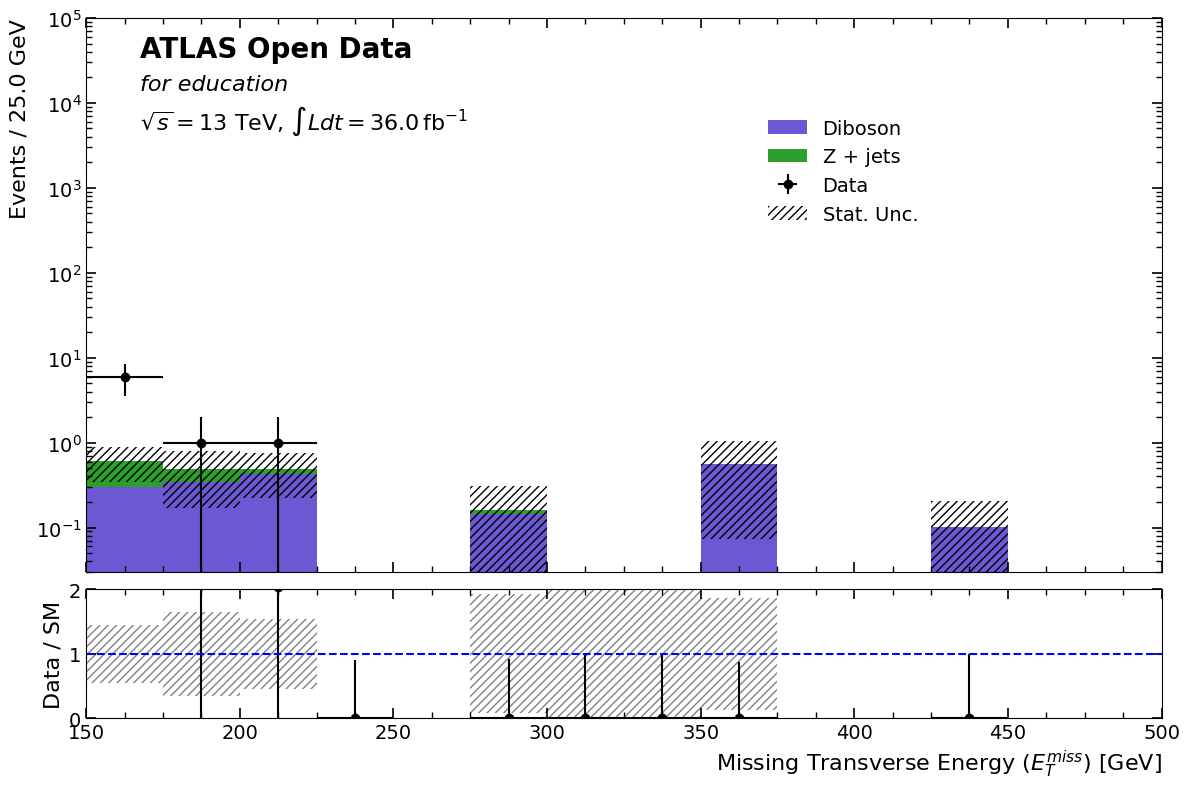

In [25]:
# define our x-axis range for histogram binining
xmin = 150 * GeV 
xmax = 500 * GeV
step_size = 25 * GeV  # bin size

bin_edges   = np.arange(xmin, xmax + step_size, step_size) # define edges of each bin
bin_centers = bin_edges[:-1] + step_size / 2 # define center of each bin


# create the figure
sizes, figsize = setup_fonts()
fig, (main_axes, residual_axes) = plt.subplots(2, 1,figsize=(12, 8), 
                                               sharex=True, gridspec_kw={'height_ratios': [3, 0.7]})

# define data to be plotted
data_vals = ak.to_numpy(all_data['data'][selected_variable])
data_hist, _ = np.histogram(data_vals, bins=bin_edges)
data_err = np.sqrt(data_hist)

# plot the data as points with errorbars
main_axes.errorbar(bin_centers, data_hist, yerr=data_err,xerr=step_size/2, fmt='ko',label='Data')


# define the background MCs with weights
bg_hists = {} # empty dictionary to hold historgams for each background
bg_w2    = {} # empty dictionary to hold weights

for bg in selected_backgrounds:
    x = ak.to_numpy(all_data[bg][selected_variable]) # MC events
    w = ak.to_numpy(all_data[bg].totalWeight) # weights

    hist, _ = np.histogram(x, bins=bin_edges, weights=w) # fill the histogram with weights
    w2, _   = np.histogram(x, bins=bin_edges, weights=w**2) # squared weights for errors

    # store values in dictionaries 
    bg_hists[bg] = hist 
    bg_w2[bg]    = w2

    
# define style of histogram
stack_vals   = [] # histogram heights 
stack_colors = [] # colors for stacked histogram
stack_labels = [] # labels for legend

# order the backgrounds for stacked histograms
for bg in bg_order:
    stack_vals.append(bg_hists[bg])
    stack_colors.append(bg_style[bg]['color'])
    stack_labels.append(bg_style[bg]['label'])

# plot the stacked backgroudn histogram
mc_heights = main_axes.hist(
    [bin_edges[:-1]] * len(stack_vals), # each background have same bin edge
    bins=bin_edges,
    weights=stack_vals,
    stacked=True,
    color=stack_colors,
    label=stack_labels,
    edgecolor=None,
    linewidth=0.6
)

# calculate total MC and uncertainty
mc_tot = np.sum(list(bg_hists.values()), axis=0) # sum all background histograms
mc_err = np.sqrt(np.sum(list(bg_w2.values()), axis=0)) # statistcial uncertainity 

# plot the error on top of the background MC
main_axes.bar(
    bin_centers,
    2 * mc_err, # height of the error band
    bottom=mc_tot - mc_err, # center the band on the histogram bin
    width=step_size,
    color='none',
    hatch='////',
    label='Stat. Unc.'
)

# define the signal MCs with weights
signal_hists = {} # dictionary to hold signal histogram
for sig in selected_signal:
    x = ak.to_numpy(all_data[sig][selected_variable]) # signal MC events
    w = ak.to_numpy(all_data[sig].totalWeight) # signal weights

    # fill histogram with weights
    hist, _ = np.histogram(x, bins=bin_edges, weights=w)
    signal_hists[sig] = hist
    
    # define style of signal 
    style = signal_style.get(sig, {})
    color = style.get('color', default_signal_style['color'])
    linestyle = style.get('linestyle', default_signal_style['linestyle'])
    label = style.get('label', f"{default_signal_style['label_prefix']}: {sig}")

    # plot the signal as line on top of the stacked background MC histogram
    main_axes.step(
    bin_edges,
    np.r_[hist, hist[-1]],
    where="post",
    linewidth=2.2,
    color=color,
    linestyle=linestyle,
    label=label
    )

# calculate and define ratio plot (Data / Background MC)
mask = mc_tot > 0 # avoid division by zero
ratio = data_hist[mask] / mc_tot[mask] # ratio of data to total MC
ratio_err = np.sqrt((data_err[mask] / mc_tot[mask])**2 + (mc_err[mask] / mc_tot[mask])**2) # uncertainity on ratio for data and MC

# plot ratio as points with errorbar
residual_axes.errorbar(
    bin_centers[mask],
    ratio,
    xerr=step_size/2,
    yerr=ratio_err,
    fmt='ko'
)

# define the correct edges for the uncertainity on the MC
ratio_low  = (mc_tot - mc_err) / mc_tot
ratio_high = (mc_tot + mc_err) / mc_tot
ratio_low_step  = np.append(ratio_low,  ratio_low[-1])
ratio_high_step = np.append(ratio_high, ratio_high[-1])

# overlay background MC error on ratio plot
residual_axes.fill_between(
    bin_edges,
    ratio_low_step,
    ratio_high_step,
    step='post',
    facecolor='none',
    hatch='////',
    edgecolor='gray',
    linewidth=0,
)

# draw line at ratio = 1.0
residual_axes.axhline(1.0, color='blue', linestyle='--')



# setup axis paramters for the main histogram
main_axes.set_yscale('log') # logrothmic scale
main_axes.set_ylim(0.03, 1e5) # y-axis range
main_axes.set_xlim(xmin, xmax) # x-axis range
main_axes.set_ylabel(f'Events / {step_size} GeV', fontsize=sizes['axes_label'], y=1, horizontalalignment='right') # label y-axis

# setup axis paramters for the ratio subplot
residual_axes.set_ylim(0, 2) # y-axis range
residual_axes.set_ylabel('Data / SM', fontsize=sizes['axes_label']) # label y-axis
residual_axes.set_xlabel(variable_labels.get(selected_variable, 'Variable'), fontsize=sizes['axes_label'], x=1.0, horizontalalignment='right') # label x-axis


# add the tick marks to the main plot and the ratio plot
setup_ticks(main_axes, tick_labelsize=sizes['tick_label'], logy=True)
setup_ticks(residual_axes, tick_labelsize=sizes['tick_label'])


# setup legends
handles, labels = main_axes.get_legend_handles_labels()

bg_h = [] # backgrounds
bg_l = [] # background labels
sig_h = [] # signals
sig_l = [] # signal labels

for h, l in zip(handles, labels):
    if l.startswith('$m ('):
        sig_h.append(h)
        sig_l.append(l)
    else:
        bg_h.append(h)
        bg_l.append(l)

# add legend to the main histogram
legend_bg = main_axes.legend(bg_h, bg_l, bbox_to_anchor=(0.79, 0.85), frameon=False, fontsize=sizes['legend'])
legend_sig = main_axes.legend(sig_h, sig_l, bbox_to_anchor=(0.98, 1.0), frameon=False, fontsize=sizes['legend'])
main_axes.add_artist(legend_bg)


# add ATLAS text to main histogram
lumi_used = str(lumi * fraction)
main_axes.text(0.05, 0.93, 'ATLAS Open Data', transform=main_axes.transAxes, fontsize=sizes['atlas_title'], fontweight='bold')
main_axes.text(0.05, 0.87, 'for education', transform=main_axes.transAxes, fontsize=sizes['atlas_subtitle'], style='italic')
main_axes.text(0.05, 0.80, rf'$\sqrt{{s}}=13$ TeV, $\int L dt = {lumi_used}\,\mathrm{{fb}}^{{-1}}$', transform=main_axes.transAxes, fontsize=sizes['atlas_lumi'])


# show the the figue
fig.tight_layout()
fig.subplots_adjust(hspace=0.05) # adjust spacing between main plot and subplot
plt.show()

**What do you think?**
- What features do we observe in the main histogram?
- Does the data agree with the total background prediction?
- How does the ratio subplot help assess this agreement?
- Is there any indication of signal excess?
- Are different background processes dominant in different regions of the distribution?


**Try it yourself!** Change one or more selection cut values and rerun the analysis. Before looking at the new plots, try to predict how loosening or tightening the requirements will affect the signal and background yields. Compare the new distributions to the original one and explore which cuts have the strongest impact.

## Statistical Interpretation

To better understand our results, we can perform a simple statistical interpretation using both the observed significance and the expected significance. Since the number of events in our analysis is relatively small, we use a statistical approximation that works well for low-event-count analyses. The significance, Z, is given in units of standard deviations from the mean. 


In particle physics, a discovery is usually claimed when the significance is greater than $5\sigma$. This means the probability of the observed excess being caused only by statistical fluctuations of the background is extremely small.


### Observed significance
The observed significance tells us how compatible the observed data is with the background-only prediction. 

We use the equation

$Z = \sqrt{2[n_{obs} ln(\frac{n_{obs}}{b})-n_{obs}+b]}$

where,
- b is the number of background events,
- $n_{obs}$ is the number of observed data events.

A larger value of Z means the observed data looks less likely to come from background processes alone. 


### Expected significance
The expected significance tells us how sensitive the analysis would be if the signal we are searching for were present. 

We use the equation

$Z = \sqrt{2[(s+b) ln(\frac{s+b}{b})-s]}$

where,
- b is the number of background events,
- s is the number of signal events. 

This gives an estimate of how strongly we would expect to observe the signal above the background. 


### Calculating Significance
Let's calculate both significance values for some of our signal models used in our analysis. 

These values are a simplified approximation since they do not consider any systematic uncertainties, but they give us an estimate of the sensitivity of our analysis. For a more in depth statistical analysis check out [this statistics notebook](https://github.com/emilypuchala/MasterThesis/blob/main/statistics_analyis.ipynb).

We start by extracting the event yields from the cutflow table we made earlier.

In [26]:
# extract the background and observed yields from our cutflow table of analysis results
# observed number of events from data
n_obs = cutflow_df.loc[cutflow_df['Process'] == 'Data', 
                       'Final Event Counts'].values[0]

# total expected background events
background = cutflow_df.loc[cutflow_df['Process'].isin(['Z+jets','Diboson','ttbar','SingleTop','W+jets']),
    'Final Event Counts'].sum()

Now, we define our significance equations and compute the values.

In [27]:
# observed significance definition
def compute_observed_significance(n_obs, background):
    with np.errstate(divide='ignore', invalid='ignore'):
        term = np.where(
            (background > 0) & (n_obs > 0),  # avoid division by zero
            2 * (n_obs * np.log(n_obs / background) - n_obs + background), # significance calculation
            0.0) # if event count < zero, retrun zero
        Z_obs = np.sqrt(term) # take square root of significance calculation
    return Z_obs


# #expected significance definition
# def compute_expected_significance(signal, background):
#     with np.errstate(divide='ignore', invalid='ignore'):
#         term = np.where(
#             (background > 0) & (signal > 0),  # avoid division by zero
#             2 * ((signal + background) * np.log((signal + background) / background) - signal), # significance calculation
#             0.0) # if event count < zero, retrun zero
#         Z_exp = np.sqrt(term) # take square root of significance calculation
#     return Z_exp


# compute the observed significance (same for all signal models, since it relies on background-only hypothesis)
Z_obs = compute_observed_significance(n_obs, background)

# print the value for the observed significance (round to 3 decimal places)
print(f"Observed significance = {Z_obs:.3f} sigma")


# #compute the expected significance for each of the signal models we plotted
# for sig in selected_signal:
#     signal = np.sum(signal_hists[sig]) # sum of the signal values in the histrogram 
#     Z_exp = compute_expected_significance(signal, background)
   
#     # print the values for the expected significance (round to 3 decimal places)
#     print(f"Expected significance for {sig} = {Z_exp:.3f} sigma")

Observed significance = 2.760 sigma


**What do you think?**
- What is the observed significance for this analysis?
- What is the expected significance for each signal model?
- Which signal model yields a greater expected significance? Does this agree with the results we saw in the histogram?
- If we considered systematic uncertainties, would you expect the significance to increase or decrease?

**Try it yourself!** Choose a different signal sample and find the expected significance.

## What's Next?
You have now completed a physics analysis and have an overview of how a supersymmetry motivated analysis is performed using real data from the ATLAS detector.This analysis is just one example and there are many ways to explore and expand upon these concepts. 


Here are some ideas for next steps:
- **Compare your results:** Look at published papers or public ATLAS results and see how your findings match or differ. ([Check out Figure 5a in this publication](https://arxiv.org/abs/1803.02762))
- **Explore additional plots:** Compare different variables, or try alternative visualizations to better understand the data.
- **Study other models:** Use this workflow as a starting point to investigate other models and frameworks.
- **Statistics:** Perform a statistical analysis and determine exlcusion limits.
- **Machine learning:** Experiment with machine learning techniques.
